In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Prepare DF for further calculation
# Check understand_data.
df = pd.read_csv('../raw/marketing.csv')
df['date_served'] = pd.to_datetime(df['date_served'], format='%m/%d/%y')

In [3]:
def retention_rate(df, cols):
    # Group by column_names and calcualte retention
    retained = df[df['is_retained'] == True].groupby(cols)['user_id'].nunique()

    # Group by column_names and calcualte conversion
    converted = df[df['converted'] == True].groupby(cols)['user_id'].nunique()

    retention_rate = retained/converted

    return retention_rate

In [4]:
def conversion_rate(df, cols):
    # Group by column_names and calcualte conversion
    converted = df[df['converted'] == True].groupby(cols)['user_id'].nunique()

    # Group by column_names and calcualte retention
    total = df.groupby(cols)['user_id'].nunique()

    conversion_rate = converted/total

    return conversion_rate

### House ads conversion rate
The house ads team has become worried about some irregularities they've noticed in conversion rate. It is common for stakeholders to come to you with concerns they've noticed around changing metrics. As a data scientist, it's your job to determine whether these changes are natural fluctuations or if they require further investigation.

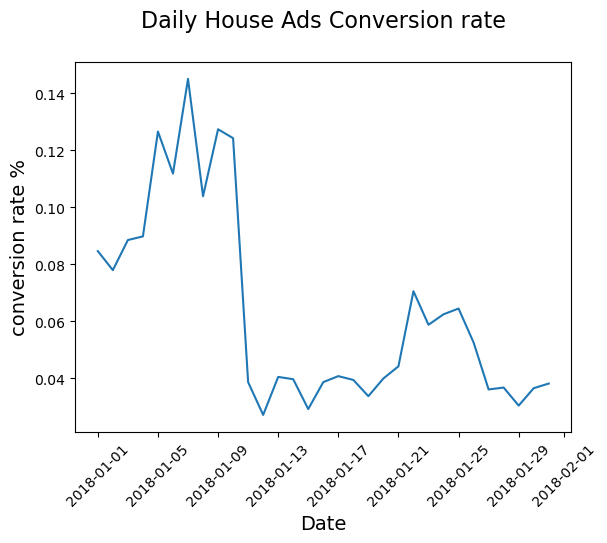

In [5]:
# Calculate conversion rate by date served and channel
daily_conv_channel = conversion_rate(df, ['date_served', 'marketing_channel'])


# Unstack daily_conv_channel and convert it to a DataFrame
daily_conv_channel = pd.DataFrame(daily_conv_channel.unstack(level = 1))

# Plot results of daily_conv_channel
plt.plot(daily_conv_channel.index, daily_conv_channel['House Ads'])
plt.title('Daily House Ads Conversion rate\n', size = 16)
plt.ylabel('conversion rate %', size = 14)
plt.xlabel('Date', size = 14)
plt.xticks(rotation = 45)
plt.show()

### Confirmed Fluctuation
Now that you have confirmed that house ads conversion has been down since January 11, you will try to identify potential causes for the decrease.

#### Hypothesis 1, DoW
<p>Is it related to DoW?</p>
It's vital to identify if the fluctuations are due to expected shifts in user behavior (i.e., differences across the day of the week) versus a larger problem in technical implementation or marketing strategy.

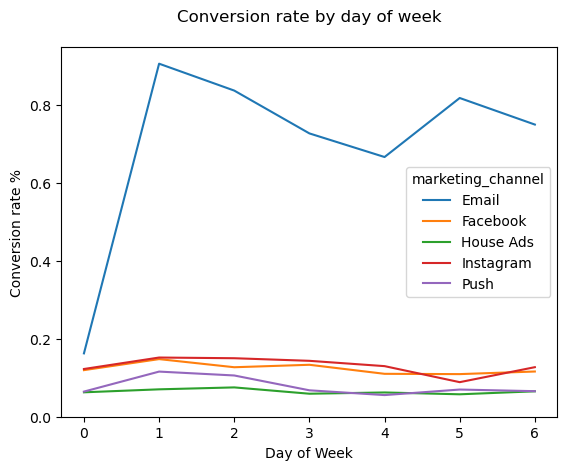

In [6]:
# Add day of week column to marketing
df['DoW_served'] = df['date_served'].dt.dayofweek

# Calculate conversion rate by day of week
DoW_conversion = conversion_rate(df, ['DoW_served', 'marketing_channel'])


# Unstack channels
DoW_df = pd.DataFrame(DoW_conversion.unstack(level=1))

# Plot conversion rate by day of week
DoW_df.plot()
plt.title('Conversion rate by day of week\n')
plt.xlabel("Day of Week")
plt.ylabel("Conversion rate %")
plt.ylim(0)
plt.show()

#### Rule Out Hypothesis 1, DoW
Now that you've ruled out natural fluctuations across the day of the week a user saw our marketing assets 

#### Hypothesis 2, Language
You will take a look at conversion by language over time. Perhaps the new marketing campaign does not apply broadly across different cultures.

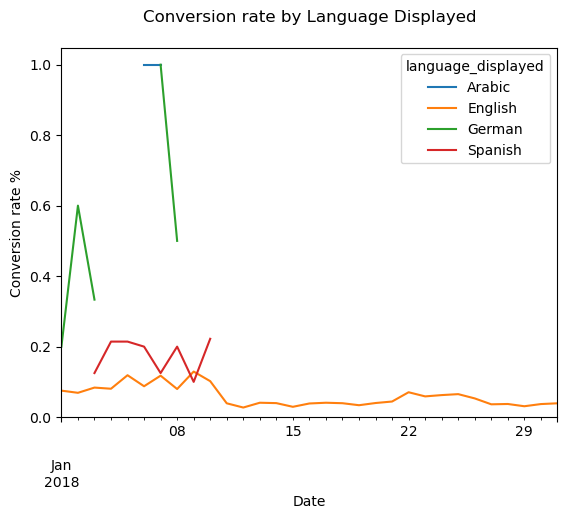

In [7]:
# Isolate the rows where marketing channel is House Ads
house_ads = df[df['marketing_channel'] == 'House Ads'].copy()

# Calculate conversion by date served, and language displayed
conv_lang_channel = conversion_rate(house_ads, ['date_served', 'language_displayed'])

# Unstack conv_lang_channel
conv_lang_df = pd.DataFrame(conv_lang_channel.unstack(level=1))

# Use your plotting function to display results
# Plot conversion rate by day of week
conv_lang_df.plot()
plt.title('Conversion rate by Language Displayed\n')
plt.xlabel("Date")
plt.ylabel("Conversion rate %")
plt.ylim(0)
plt.show()

#### Confirmed Hypothesis 2, Language
you confirmed that conversion is down because you noticed a pattern around language preferences.

In [8]:
# Add the new column is_correct_lang
house_ads['is_correct_lang'] = np.where(
    house_ads['language_displayed'] == house_ads['language_preferred'], 
    'Yes', 
    'No')

# Groupby date_served and correct_language
language_check = house_ads.groupby(['date_served', 'is_correct_lang'])['user_id'].count()

# Unstack language_check and fill missing values with 0's
language_check_df = pd.DataFrame(language_check.unstack(level=1)).fillna(0)

# Print results
language_check_df.head(20)

is_correct_lang,No,Yes
date_served,,
2018-01-01,2.0,189.0
2018-01-02,3.0,247.0
2018-01-03,0.0,220.0
2018-01-04,0.0,168.0
2018-01-05,0.0,160.0
2018-01-06,1.0,151.0
2018-01-07,2.0,130.0
2018-01-08,0.0,154.0
2018-01-09,0.0,157.0


#### Confirmed Bug
There is a problem with language. The number of ads showing to unpreferred langauge jumped at 11, Jan. 

Identified a dip in conversion rates for House Ads. It appears that the problem was that users were seeing ads in languages other than there preferred language. 

In [9]:
# Divide the count where language is correct by the row sum
language_check_df['pct'] = language_check_df['Yes']/language_check_df.sum(axis=1)


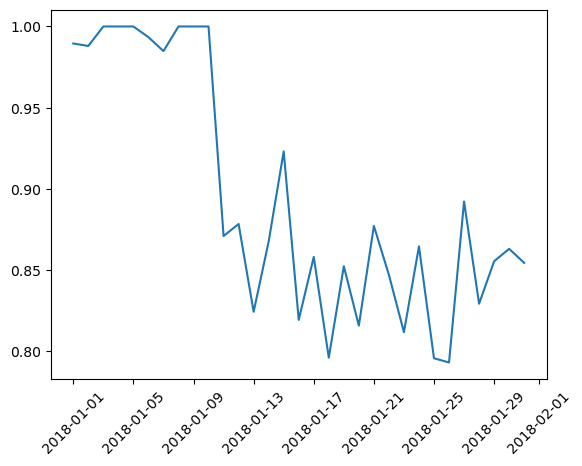

In [10]:
# Plot and show your results
plt.plot(language_check_df.index, language_check_df['pct'])
plt.xticks(rotation = 45)
plt.show()

Fig 1: Conversion rate by Language Displayed မှာလဲ တခြား Language အတွက် ဒေတာတွေ ပျောက်သွားတယ်။ English အတွက်ပဲ Data ရှိတယ်၊ သူလဲပဲ conversion rate ကျတယ်။ Prefered Language နဲ့ Ads မြင်ရတာ ဟုတ်ရဲ့လား စစ်ကြည့်တော့ သူ့မှာလဲ ကျနေတယ်။ ပြသနာက လူတွေအားလုံးဆီကို English Language နဲ့ပဲ ကြော်ညာသွားပြတာ။

ဒီလို အမှားဖြစ်သွားတဲ့ အတွက် ဘယ်လောက်ဆုံးရှုံးမလဲ တွက်ကြည့်ဖို့ ပြသနာ မဖြစ်ခင်က Data ကိုရှာ၊ Index ထုတ်။ အဲ Index ပေါ်မူတည်ပြီး Expected Count ကို ပြန်ထုတ်။

Error က Language Displayed မှာဖြစ်တဲ့အတွက်၊ Language Preferred ပေါ်မူတည်ပြီး အဖြေပြန်ရှာလို့ရတယ်။
ကြော်ညာတွေ အားလုံးက English နဲ့ပြတာ ဖြစ်တဲ့အတွက် Language Preferred = 'English' ဖြစ်တဲ့သူ ပေါ်မူတည်ပြီး ပြန်ရှာလို့ရတယ်။


In [11]:
# Calculate pre-error conversion rate
house_ads_bug = house_ads[house_ads['date_served'] < '2018-01-11']
lang_conv = conversion_rate(house_ads_bug, ['language_displayed'])

# Index other language conversion rate against English
spanish_index = lang_conv['Spanish']/lang_conv['English']
arabic_index = lang_conv['Arabic']/lang_conv['English']
german_index =lang_conv['German']/lang_conv['English']

print("Spanish index:", spanish_index)
print("Arabic index:", arabic_index)
print("German index:", german_index)


Spanish index: 1.681924882629108
Arabic index: 5.045774647887324
German index: 4.485133020344287


In [26]:
# Group house_ads by date and language
converted = house_ads.groupby(['date_served', 'language_preferred'])\
                        .agg({'user_id':'nunique',
                              'converted':'sum'})

# Unstack converted
converted = pd.DataFrame(converted.unstack(level = 1))

print(converted)

                   user_id                        converted                 \
language_preferred  Arabic English German Spanish    Arabic English German   
date_served                                                                  
2018-01-01             2.0   171.0    5.0    11.0         2      13      1   
2018-01-02             3.0   200.0    5.0    10.0         0      14      3   
2018-01-03             2.0   179.0    3.0     8.0         0      15      1   
2018-01-04             2.0   149.0    2.0    14.0         0      12      0   
2018-01-05             NaN   143.0    1.0    14.0       NaN      17  False   
2018-01-06             3.0   136.0    2.0    11.0         3      12      0   
2018-01-07             2.0   117.0    2.0    10.0         2      14      2   
2018-01-08             NaN   138.0    6.0    10.0       NaN      11      3   
2018-01-09             NaN   147.0    NaN    10.0       NaN      19    NaN   
2018-01-10             NaN   147.0    4.0    18.0       NaN     

In [33]:
# Create English conversion rate column for affected period
converted['english_conv_rate'] = converted.loc['2018-01-11':'2018-01-31'][('converted', 'English')]/converted.loc['2018-01-11':'2018-01-31'][('user_id', 'English')]


# Create expected conversion rates for each language
converted['expected_spanish_rate'] = converted['english_conv_rate'] * spanish_index
converted['expected_arabic_rate'] = converted['english_conv_rate'] * arabic_index
converted['expected_german_rate'] = converted['english_conv_rate'] * german_index

# Multiply number of users by the expected conversion rate
converted['expected_spanish_conv'] = converted['expected_spanish_rate']*converted[('user_id', 'Spanish')]
converted['expected_arabic_conv'] = converted['expected_arabic_rate']*converted[('user_id', 'Arabic')]
converted['expected_german_conv'] = converted['expected_german_rate']*converted[('user_id', 'German')]

print(converted)

                   user_id                        converted                 \
language_preferred  Arabic English German Spanish    Arabic English German   
date_served                                                                  
2018-01-11             7.0   133.0    2.0    13.0         0       6      0   
2018-01-12             3.0   129.0    4.0    11.0         0       3      0   
2018-01-13             6.0   121.0    5.0    16.0         0       5      1   
2018-01-14             5.0   131.0    3.0    12.0         0       6      0   
2018-01-15             2.0   189.0    4.0    10.0         0       6      0   
2018-01-16             7.0   127.0    4.0    17.0         0       6      0   
2018-01-17             2.0   126.0    3.0    16.0         0       2      0   
2018-01-18             7.0   121.0    6.0    18.0         0       5      1   
2018-01-19             5.0   126.0    5.0    12.0         1       4      0   
2018-01-20             6.0   124.0    6.0    14.0         1     

C:\Users\sawyu\AppData\Local\Temp\ipykernel_11932\2192297362.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  converted['english_conv_rate'] = converted.loc['2018-01-11':'2018-01-31'][('converted', 'English')]/converted.loc['2018-01-11':'2018-01-31'][('user_id', 'English')]
C:\Users\sawyu\AppData\Local\Temp\ipykernel_11932\2192297362.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  converted['expected_spanish_rate'] = converted['english_conv_rate'] * spanish_index
C:\Users\sawyu\AppData\Local\Temp\ipy

In [34]:
# Use .loc to slice only the relevant dates
converted = converted.loc['2018-01-11':'2018-01-31']

# Sum expected subscribers for each language
expected_subs = converted['expected_spanish_conv'].sum() + converted['expected_arabic_conv'].sum() + converted['expected_german_conv'].sum()

# Calculate how many subscribers we actually got
actual_subs = converted[('converted', 'Spanish')].sum() + converted[('converted', 'Arabic')].sum() + converted[('converted', 'German')].sum()

# Subtract how many subscribers we got despite the bug
lost_subs = expected_subs - actual_subs
print(lost_subs)

24.457492473820594
